In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os

# Functions

Found 312 pulses in this data window.


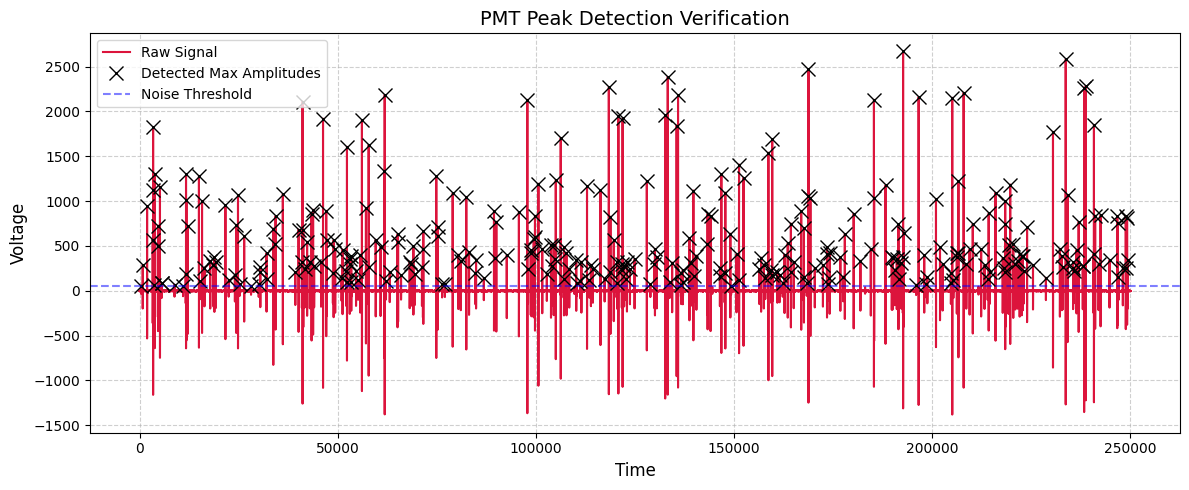

In [22]:
import os
import numpy as np
import matplotlib.pyplot as plt
import scipy.signal as signal
from scipy.signal import find_peaks

def graph_pulse_amplitudes(file_path, data_format='int16', start_idx=0, num_points=10000, invert_signal=False):
    """
    Reads PMT data, finds pulse peaks, and plots them for verification.
    """
    if not os.path.exists(file_path):
        print(f"Error: File '{file_path}' not found.")
        return

    # 1. Load the data slice
    data = np.fromfile(file_path, dtype=data_format)
    y_data = data[start_idx : start_idx + num_points]
    x_data = np.arange(start_idx, start_idx + len(y_data))

    # 2. Invert the signal if PMT outputs negative pulses
    if invert_signal:
        analyze_data = y_data * -1
    else:
        analyze_data = y_data
        
    # height: The minimum voltage threshold to be considered a pulse (ignores baseline noise)
    # distance: The minimum number of samples between peaks (prevents double-counting a single noisy peak)
    # prominence: How much the peak stands out from the surrounding baseline
    
    noise_threshold = 50 # 50mV threshold
    min_samples_between_pulses = 10
    
    peaks, properties = find_peaks(analyze_data, height=noise_threshold, distance=min_samples_between_pulses)
    
    # Extract the raw amplitudes 
    # (If we inverted the signal, we use the original y_data to get the true voltage values)
    peak_amplitudes = y_data[peaks]
    
    print(f"Found {len(peaks)} pulses in this data window.")
    
    # Plot the waveform and the detected peaks to verify it's working
    plt.figure(figsize=(12, 5))
    plt.plot(x_data, y_data, color='crimson', linewidth=1.5, label='Raw Signal')
    
    # Mark the peaks
    plt.plot(x_data[peaks], peak_amplitudes, "x", color='black', markersize=10, label='Detected Max Amplitudes')
    
    # Draw a line showing the threshold (flip it back if inverted for analysis)
    plot_threshold = -noise_threshold if invert_signal else noise_threshold
    plt.axhline(y=plot_threshold, color='blue', linestyle='--', alpha=0.5, label='Noise Threshold')
    
    plt.title("PMT Peak Detection Verification", fontsize=14)
    plt.xlabel("Time", fontsize=12)
    plt.ylabel("Voltage", fontsize=12)
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()
    
    return peak_amplitudes # Returns the array of max voltages

my_file = r"C:\Users\Berkeley\Documents\CERES\welding_rod_200khz\20260422_01h37.BINPMT"
amplitudes = graph_pulse_amplitudes(my_file, data_format="int16", num_points= 250000, invert_signal=False)

Found 1 pulses in this data window.


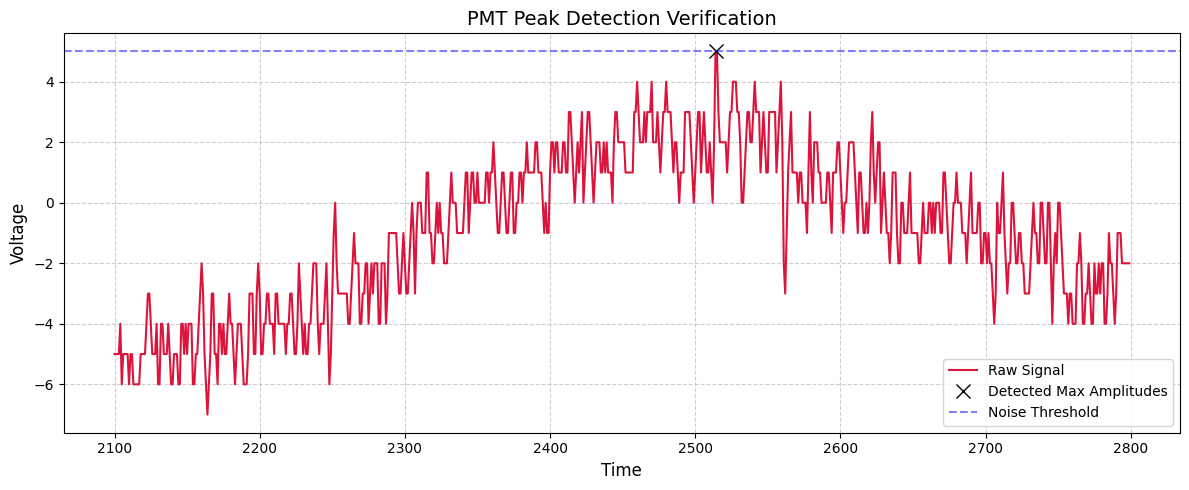

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import scipy.signal as signal
from scipy.signal import find_peaks

def graph_pulse_amplitudes(file_path, data_format='int16', start_idx=0, num_points=10000, invert_signal=False):
    """
    Reads PMT data, finds pulse peaks, and plots them for verification.
    """
    if not os.path.exists(file_path):
        print(f"Error: File '{file_path}' not found.")
        return

    # 1. Load the data slice
    data = np.fromfile(file_path, dtype=data_format)
    y_data = data[start_idx : start_idx + num_points]
    x_data = np.arange(start_idx, start_idx + len(y_data))

    # 2. Invert the signal if PMT outputs negative pulses
    if invert_signal:
        analyze_data = y_data * -1
    else:
        analyze_data = y_data
        
    # height: The minimum voltage threshold to be considered a pulse (ignores baseline noise)
    # distance: The minimum number of samples between peaks (prevents double-counting a single noisy peak)
    # prominence: How much the peak stands out from the surrounding baseline
    
    noise_threshold = 6
    min_samples_between_pulses = 10 
    
    peaks, properties = find_peaks(analyze_data, height=noise_threshold, distance=min_samples_between_pulses)
    
    # Extract the raw amplitudes 
    # (If we inverted the signal, we use the original y_data to get the true voltage values)
    peak_amplitudes = y_data[peaks]
    
    print(f"Found {len(peaks)} pulses in this data window.")
    
    # Plot the waveform and the detected peaks to verify it's working
    plt.figure(figsize=(12, 5))
    plt.plot(x_data, y_data, color='crimson', linewidth=1.5, label='Raw Signal')
    
    # Mark the peaks
    plt.plot(x_data[peaks], peak_amplitudes, "x", color='black', markersize=10, label='Detected Max Amplitudes')
    
    # Draw a line showing the threshold (flip it back if inverted for analysis)
    plot_threshold = -noise_threshold if invert_signal else noise_threshold
    plt.axhline(y=plot_threshold, color='blue', linestyle='--', alpha=0.5, label='Noise Threshold')
    
    plt.title("PMT Peak Detection Verification", fontsize=14)
    plt.xlabel("Time", fontsize=12)
    plt.ylabel("Voltage", fontsize=12)
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()
    
    return peak_amplitudes # Returns the array of max voltages

my_file = r"C:\Users\Berkeley\Documents\CERES\welding_rod_200khz\20260422_01h37.BINPMT"
amplitudes = graph_pulse_amplitudes(my_file, data_format="int16", start_idx=2100, num_points= 700, invert_signal=False)

In [3]:
import os
import numpy as np
import matplotlib.pyplot as plt
import scipy.signal as signal
from scipy.signal import find_peaks

def extract_pulse_amplitudes(file_path, data_format='int16', start_idx=0, num_points=10000, invert_signal=False):
    """
    Reads PMT data, finds pulse peaks, and plots them for verification.
    """
    if not os.path.exists(file_path):
        print(f"Error: File '{file_path}' not found.")
        return

    # 1. Load the data slice
    data = np.fromfile(file_path, dtype=data_format)
    y_data = data[start_idx : start_idx + num_points]
    x_data = np.arange(start_idx, start_idx + len(y_data))

    # 2. Invert the signal if PMT outputs negative pulses
    if invert_signal:
        analyze_data = y_data * -1
    else:
        analyze_data = y_data
        
    # height: The minimum voltage threshold to be considered a pulse (ignores baseline noise)
    # distance: The minimum number of samples between peaks (prevents double-counting a single noisy peak)
    # prominence: How much the peak stands out from the surrounding baseline
    
    noise_threshold = 0.05 # 50mV threshold
    min_samples_between_pulses = 10 
    
    peaks, properties = find_peaks(analyze_data, height=noise_threshold, distance=min_samples_between_pulses)
    
    # Extract the raw amplitudes 
    # (If we inverted the signal, we use the original y_data to get the true voltage values)
    peak_amplitudes = y_data[peaks]
    
    print(f"Found {len(peaks)} pulses in this data window.")
    
    return peak_amplitudes # Returns the array of max voltages

Plotting histogram for 4,197 detected pulses...


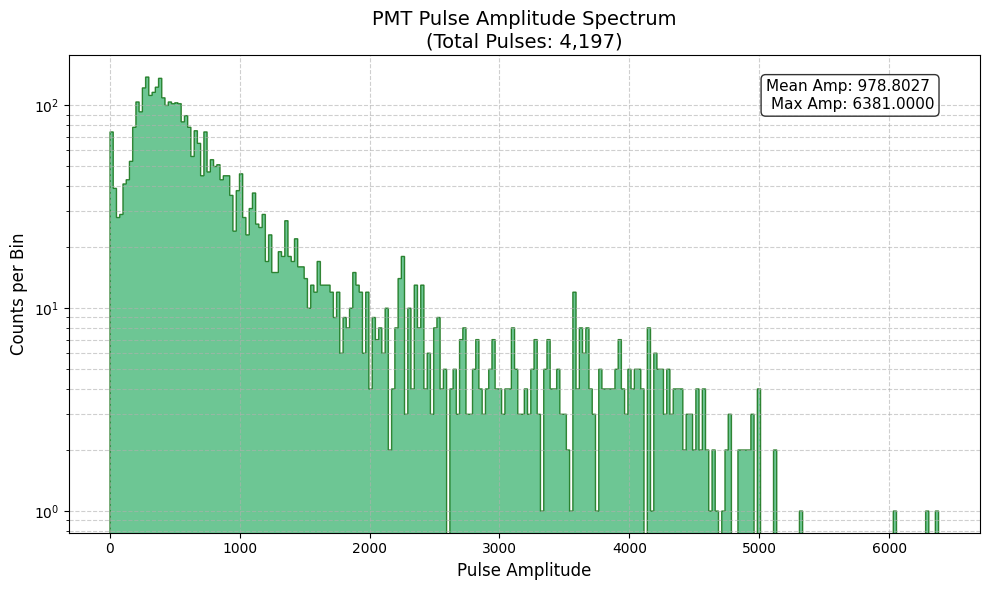

In [4]:
import numpy as np
import matplotlib.pyplot as plt

def plot_amplitude_histogram(amplitudes, num_bins=512, log_scale=True):
    """
    Takes an array of pulse amplitudes and plots them as a histogram (spectrum).
    
    Parameters:
    amplitudes (array-like): The list or numpy array of max pulse amplitudes.
    num_bins (int): Number of bins. 512, 1024, or 'auto' are standard.
    log_scale (bool): Whether to use a logarithmic y-axis (highly recommended for PMTs).
    """
    
    # Check if we actually have data to plot
    if amplitudes is None or len(amplitudes) == 0:
        print("Error: The amplitudes array is empty. No pulses were found.")
        return

    print(f"Plotting histogram for {len(amplitudes):,} detected pulses...")

    plt.figure(figsize=(10, 6))
    
    # Plot the histogram using the 'stepfilled'
    counts, bins, patches = plt.hist(amplitudes, bins=num_bins, color='mediumseagreen', 
                                     alpha=0.75, histtype='stepfilled', edgecolor='darkgreen')
    
    # Apply Logarithmic Scale
    # Log scale is vital because dark noise pulses usually outnumber real photon pulses
    if log_scale:
        plt.yscale('log')
        plt.grid(True, linestyle='--', alpha=0.6, which='both') # Show grid for minor log ticks
    else:
        plt.grid(True, linestyle='--', alpha=0.6)

    # Stats
    mean_amp = np.mean(amplitudes)
    max_amp = np.max(amplitudes)
    
    plt.title(f"PMT Pulse Amplitude Spectrum\n(Total Pulses: {len(amplitudes):,})", fontsize=14)
    plt.xlabel("Pulse Amplitude", fontsize=12)
    plt.ylabel("Counts per Bin", fontsize=12)
    
    # Add a text box with statistics
    
    stats_text = f"Mean Amp: {mean_amp:.4f} \nMax Amp: {max_amp:.4f}"
    plt.text(0.95, 0.95, stats_text, transform=plt.gca().transAxes, 
             fontsize=11, verticalalignment='top', horizontalalignment='right',
             bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

    plt.tight_layout()
    plt.show()


my_file = r"C:\Users\Berkeley\Documents\CERES\pmt5000hrtzfiles\20260331_15h50.BINPMT"


# Plot the spectrum!
plot_amplitude_histogram(amplitudes, num_bins=256, log_scale=True)

In [5]:
extract_pulse_amplitudes(my_file, data_format="int16", num_points= 10000, invert_signal=False)

Found 197 pulses in this data window.


array([  83, 4368,  488,  231, 1747,  681, 1689,  103,  216,  705,  497,
        630,  664, 3776,  740, 1086,  295,  681,  346,  785,  485, 2851,
       3987, 1566,  163,   73,  478,  538,  274,  366,  738, 1581,  300,
        672,  557,  194,  277,  132,  302,  425,  497,  995,  384, 2519,
        983,  598,  581,  328,    7,  393,  236, 3257,  513, 4110,  413,
       1130, 1020,  488,  163, 3568,   38,  417,  115, 3695, 2494, 1161,
        114,  520, 1406, 4006,  333,  156,  141,  142,  716,  656, 2255,
        545,  875, 1886, 1690,  189,  283,  386,  524, 1334,   17,  849,
        299,  450,  724, 4600,  693,   85, 4516,  340,  491,  552, 1891,
        284,  934,  431, 3510,  627, 2901,  372,  263, 1106,  782,  214,
       1533, 4838, 1014,  746,  393,  586, 1396,  385,   31,  210,  514,
       1013, 1316,  789,  818, 4452,  710, 1702,  285, 1694, 1385, 2573,
       2455, 1110,  202,  654,  279,  377,  591,  587,  869, 2092,  239,
       2875, 1091, 1162,  831, 1146, 2414,  470,  5

------------------------------
Calculated True Baseline (Median): -2.000000
Skewed Average (Mean):             -1.683528
------------------------------


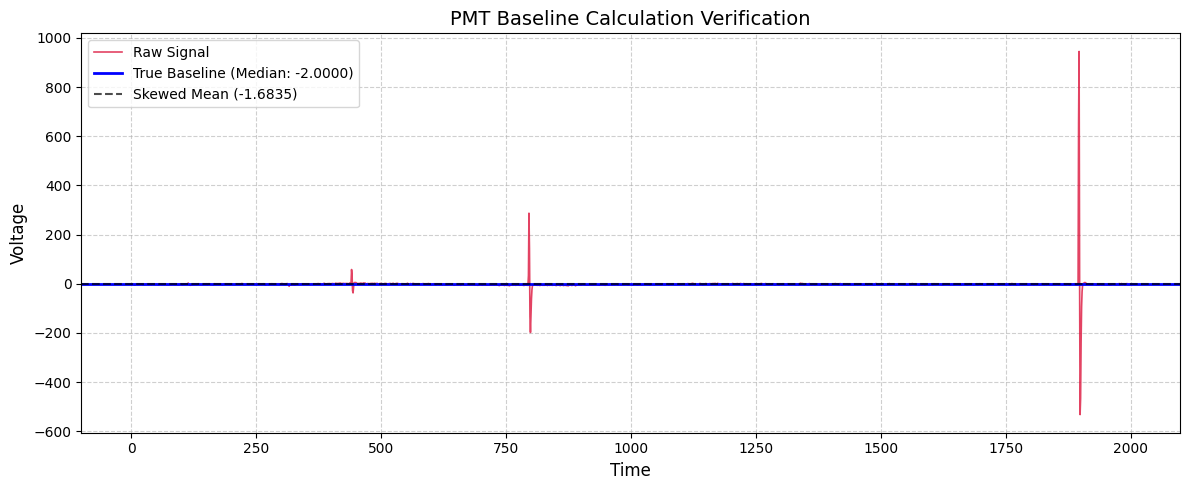

In [10]:
import os
import numpy as np
import matplotlib.pyplot as plt

def calculate_pmt_baseline(file_path, data_format='int16', analyze_points=250000):
    """
    Calculates the resting baseline of a PMT signal using the median to ignore pulse spikes.
    
    Parameters:
    file_path (str): The path to your binary file.
    data_format (str): The specific 32-bit format ('float32', 'int16', 'uint32').
    analyze_points (int): How many data points to use for the calculation. 100,000 is 
                          usually plenty to get a statistically perfect baseline without 
                          loading massive files into memory all at once.
    """
    if not os.path.exists(file_path):
        print(f"Error: File '{file_path}' not found.")
        return

    try:
        # Load a chunk of data to calculate the baseline
        data = np.fromfile(file_path, dtype=data_format, count=analyze_points)
        
        # Calculate Baseline using Median (Robust against pulse spikes)
        true_baseline = np.median(data)
        
        # Calculate simple Mean for comparison (Usually skewed by pulses)
        skewed_mean = np.mean(data)
        
        print("-" * 30)
        print(f"Calculated True Baseline (Median): {true_baseline:.6f}")
        print(f"Skewed Average (Mean):             {skewed_mean:.6f}")
        print("-" * 30)
        
        # Visualize a small slice to verify the baseline visually
        plot_points = min(2000, len(data)) # Plot just enough to see the noise and pulses
        y_data = data[:plot_points]
        x_data = np.arange(plot_points)

        plt.figure(figsize=(12, 5))
        plt.plot(x_data, y_data, color='crimson', linewidth=1.2, alpha=0.8, label='Raw Signal')
        
        # Draw the baselines
        plt.axhline(y=true_baseline, color='blue', linestyle='-', linewidth=2, 
                    label=f'True Baseline (Median: {true_baseline:.4f})')
        
        plt.axhline(y=skewed_mean, color='black', linestyle='--', linewidth=1.5, alpha=0.7,
                    label=f'Skewed Mean ({skewed_mean:.4f})')

        plt.title("PMT Baseline Calculation Verification", fontsize=14)
        plt.xlabel("Time", fontsize=12)
        plt.ylabel("Voltage", fontsize=12)
        plt.legend()
        plt.grid(True, linestyle='--', alpha=0.6)
        plt.tight_layout()
        plt.show()
        
        return true_baseline

    except Exception as e:
        print(f"An error occurred: {e}")

my_file = r"C:\Users\Berkeley\Documents\CERES\welding_rod_200khz\20260422_01h37.BINPMT"
baseline_voltage = calculate_pmt_baseline(my_file, data_format='int16')

Found 7 files to process.

Processing: 20260421_21h27.BINPMT
  -> Found 1,296,167 pulses (processed 1,001,000,000 points).
Processing: 20260421_22h50.BINPMT
  -> Found 1,297,070 pulses (processed 1,001,000,000 points).
Processing: 20260422_00h13.BINPMT
  -> Found 1,297,269 pulses (processed 1,001,000,000 points).
Processing: 20260422_01h37.BINPMT
  -> Found 1,298,352 pulses (processed 1,001,000,000 points).
Processing: 20260422_03h00.BINPMT
  -> Found 1,297,315 pulses (processed 1,001,000,000 points).
Processing: 20260422_04h24.BINPMT
  -> Found 1,298,915 pulses (processed 1,001,000,000 points).
Processing: 20260422_05h47.BINPMT
  -> Found 1,296,222 pulses (processed 1,001,000,000 points).

Plotting combined histogram for 9,081,310 detected pulses...


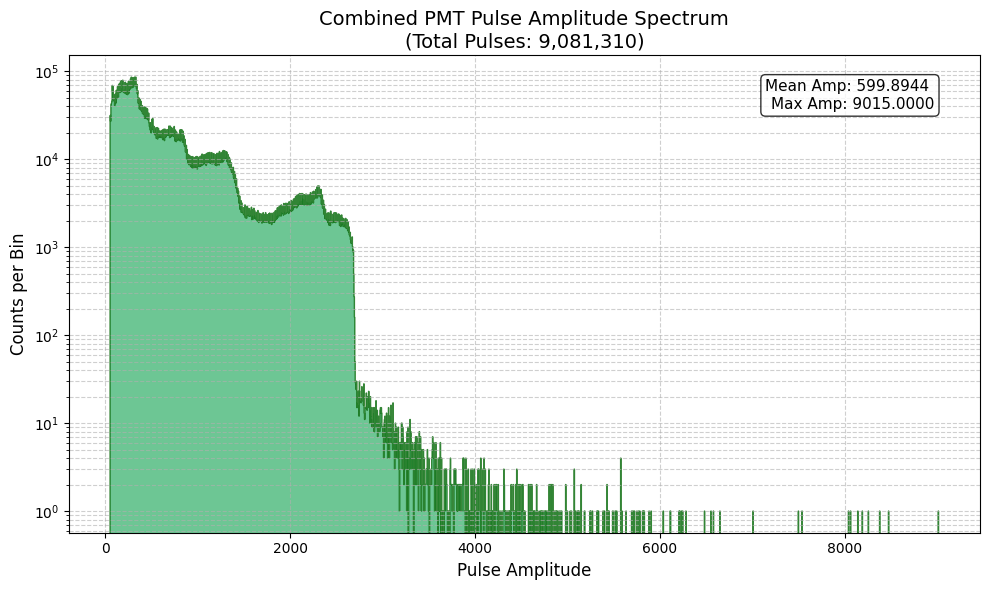

In [23]:
import os
import glob
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

def extract_pulse_amplitudes(file_path, data_format='int16', chunk_size=10_000_000, invert_signal=False):
    """
    Reads PMT data in chunks from disk, finds pulse peaks, and returns them.
    This prevents MemoryErrors on extremely large files.
    """
    if not os.path.exists(file_path):
        print(f"Error: File '{file_path}' not found.")
        return []

    # 1. Use memmap to map the file from disk without loading it all into RAM
    data = np.memmap(file_path, dtype=data_format, mode='r')
    total_points = len(data)
    
    # Pulse parameters
    noise_threshold = 50
    min_samples_between_pulses = 10 
    
    # Create an overlap buffer so we don't split a pulse across two chunks
    overlap = min_samples_between_pulses * 2 
    
    all_peak_amplitudes = []

    # 2. Process the file in chunks
    for start_idx in range(0, total_points, chunk_size):
        end_idx = min(start_idx + chunk_size + overlap, total_points)
        
        # Extract just this specific chunk into active memory
        chunk = data[start_idx:end_idx]
        
        if invert_signal:
            analyze_chunk = chunk * -1
        else:
            analyze_chunk = chunk
            
        # Find peaks in this chunk
        peaks, _ = find_peaks(analyze_chunk, height=noise_threshold, distance=min_samples_between_pulses)
        
        # 3. Prevent double-counting in the overlap region
        if end_idx < total_points:
            valid_peaks = peaks[peaks < chunk_size]
        else:
            valid_peaks = peaks
            
        # Get the actual voltage values for these peaks
        chunk_amplitudes = chunk[valid_peaks]
        all_peak_amplitudes.extend(chunk_amplitudes)
        
    print(f"  -> Found {len(all_peak_amplitudes):,} pulses (processed {total_points:,} points).")
    
    return all_peak_amplitudes

def plot_amplitude_histogram(amplitudes, num_bins=512, log_scale=True):
    """
    Takes an array of pulse amplitudes and plots them as a histogram (spectrum).
    """
    if amplitudes is None or len(amplitudes) == 0:
        print("Error: The amplitudes array is empty. No pulses were found.")
        return

    print(f"\nPlotting combined histogram for {len(amplitudes):,} detected pulses...")

    plt.figure(figsize=(10, 6))
    
    # Plot the histogram using 'stepfilled'
    counts, bins, patches = plt.hist(amplitudes, bins=num_bins, color='mediumseagreen', 
                                     alpha=0.75, histtype='stepfilled', edgecolor='darkgreen')
    
    # Apply Logarithmic Scale
    if log_scale:
        plt.yscale('log')
        plt.grid(True, linestyle='--', alpha=0.6, which='both') 
    else:
        plt.grid(True, linestyle='--', alpha=0.6)

    # Stats
    mean_amp = np.mean(amplitudes)
    max_amp = np.max(amplitudes)
    
    plt.title(f"Combined PMT Pulse Amplitude Spectrum\n(Total Pulses: {len(amplitudes):,})", fontsize=14)
    plt.xlabel("Pulse Amplitude", fontsize=12)
    plt.ylabel("Counts per Bin", fontsize=12)
    
    # Add a text box with statistics
    stats_text = f"Mean Amp: {mean_amp:.4f} \nMax Amp: {max_amp:.4f}"
    plt.text(0.95, 0.95, stats_text, transform=plt.gca().transAxes, 
             fontsize=11, verticalalignment='top', horizontalalignment='right',
             bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

    plt.tight_layout()
    plt.show()


# ==========================================
# Main Execution Block
# ==========================================

# 1. Define the folder containing your files
folder_path = r"C:\Users\Berkeley\Documents\CERES\welding_rod_200khz"

# 2. Find all .BINPMT files in that folder
file_pattern = os.path.join(folder_path, "*.BINPMT")
file_list = glob.glob(file_pattern)

if not file_list:
    print(f"No .BINPMT files found in {folder_path}")
else:
    print(f"Found {len(file_list)} files to process.\n")

    # List to hold all amplitudes across all files
    all_amplitudes = []

    # 3. Loop through the files
    for file_path in file_list:
        file_name = os.path.basename(file_path)
        print(f"Processing: {file_name}")
        
        # Extract pulses (processing in chunks to save memory)
        # Replaced num_points with chunk_size
        file_amplitudes = extract_pulse_amplitudes(file_path, chunk_size=10_000_000, invert_signal=False)
        
        # Add the extracted amplitudes to our master list
        if file_amplitudes is not None and len(file_amplitudes) > 0:
            all_amplitudes.extend(file_amplitudes)

    # 4. Convert the combined list to a numpy array for plotting
    all_amplitudes = np.array(all_amplitudes)

    # 5. Plot the combined spectrum!
    plot_amplitude_histogram(all_amplitudes, num_bins=2048, log_scale=True)

Found 3 files to process.

Processing: 20260430_16h07.BINPMT
  -> Found 465,782 pulses (processed 1,001,000,000 points).
Processing: 20260430_17h30.BINPMT
  -> Found 423,804 pulses (processed 1,001,000,000 points).
Processing: 20260430_18h54.BINPMT
  -> Found 212,274 pulses (processed 486,000,000 points).

Plotting combined histogram for 1,101,860 detected pulses...


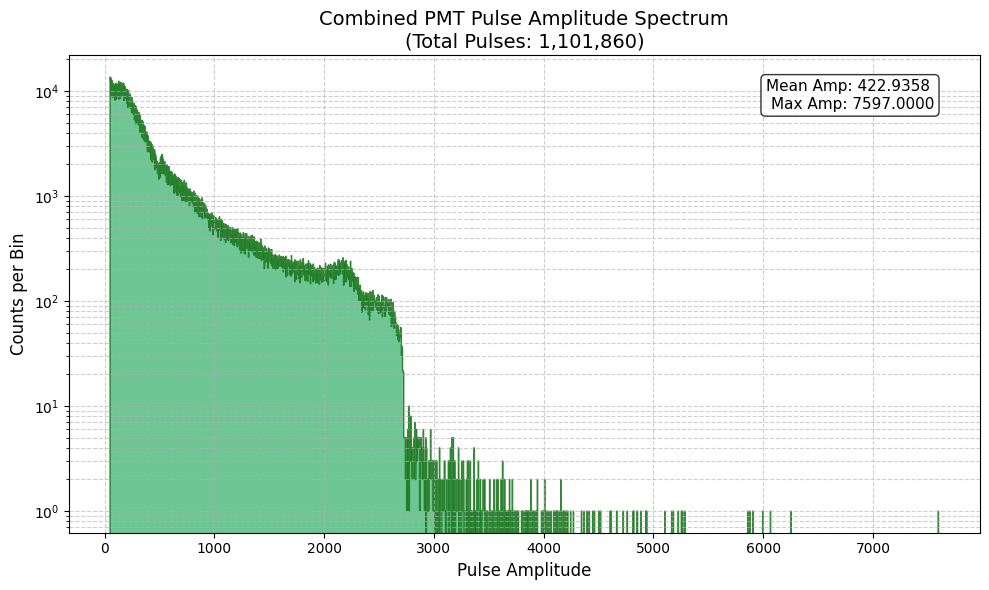

In [24]:
import os
import glob
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

def extract_pulse_amplitudes(file_path, data_format='int16', chunk_size=10_000_000, invert_signal=False):
    """
    Reads PMT data in chunks from disk, finds pulse peaks, and returns them.
    This prevents MemoryErrors on extremely large files.
    """
    if not os.path.exists(file_path):
        print(f"Error: File '{file_path}' not found.")
        return []

    # 1. Use memmap to map the file from disk without loading it all into RAM
    data = np.memmap(file_path, dtype=data_format, mode='r')
    total_points = len(data)
    
    # Pulse parameters
    noise_threshold = 50
    min_samples_between_pulses = 10 
    
    # Create an overlap buffer so we don't split a pulse across two chunks
    overlap = min_samples_between_pulses * 2 
    
    all_peak_amplitudes = []

    # 2. Process the file in chunks
    for start_idx in range(0, total_points, chunk_size):
        end_idx = min(start_idx + chunk_size + overlap, total_points)
        
        # Extract just this specific chunk into active memory
        chunk = data[start_idx:end_idx]
        
        if invert_signal:
            analyze_chunk = chunk * -1
        else:
            analyze_chunk = chunk
            
        # Find peaks in this chunk
        peaks, _ = find_peaks(analyze_chunk, height=noise_threshold, distance=min_samples_between_pulses)
        
        # 3. Prevent double-counting in the overlap region
        if end_idx < total_points:
            valid_peaks = peaks[peaks < chunk_size]
        else:
            valid_peaks = peaks
            
        # Get the actual voltage values for these peaks
        chunk_amplitudes = chunk[valid_peaks]
        all_peak_amplitudes.extend(chunk_amplitudes)
        
    print(f"  -> Found {len(all_peak_amplitudes):,} pulses (processed {total_points:,} points).")
    
    return all_peak_amplitudes

def plot_amplitude_histogram(amplitudes, num_bins=512, log_scale=True):
    """
    Takes an array of pulse amplitudes and plots them as a histogram (spectrum).
    """
    if amplitudes is None or len(amplitudes) == 0:
        print("Error: The amplitudes array is empty. No pulses were found.")
        return

    print(f"\nPlotting combined histogram for {len(amplitudes):,} detected pulses...")

    plt.figure(figsize=(10, 6))
    
    # Plot the histogram using 'stepfilled'
    counts, bins, patches = plt.hist(amplitudes, bins=num_bins, color='mediumseagreen', 
                                     alpha=0.75, histtype='stepfilled', edgecolor='darkgreen')
    
    # Apply Logarithmic Scale
    if log_scale:
        plt.yscale('log')
        plt.grid(True, linestyle='--', alpha=0.6, which='both') 
    else:
        plt.grid(True, linestyle='--', alpha=0.6)

    # Stats
    mean_amp = np.mean(amplitudes)
    max_amp = np.max(amplitudes)
    
    plt.title(f"Combined PMT Pulse Amplitude Spectrum\n(Total Pulses: {len(amplitudes):,})", fontsize=14)
    plt.xlabel("Pulse Amplitude", fontsize=12)
    plt.ylabel("Counts per Bin", fontsize=12)
    
    # Add a text box with statistics
    stats_text = f"Mean Amp: {mean_amp:.4f} \nMax Amp: {max_amp:.4f}"
    plt.text(0.95, 0.95, stats_text, transform=plt.gca().transAxes, 
             fontsize=11, verticalalignment='top', horizontalalignment='right',
             bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

    plt.tight_layout()
    plt.show()


# ==========================================
# Main Execution Block
# ==========================================

# 1. Define the folder containing your files
folder_path = r"C:\Users\Berkeley\Documents\CERES\shaping_nosource"

# 2. Find all .BINPMT files in that folder
file_pattern = os.path.join(folder_path, "*.BINPMT")
file_list = glob.glob(file_pattern)

if not file_list:
    print(f"No .BINPMT files found in {folder_path}")
else:
    print(f"Found {len(file_list)} files to process.\n")

    # List to hold all amplitudes across all files
    all_amplitudes = []

    # 3. Loop through the files
    for file_path in file_list:
        file_name = os.path.basename(file_path)
        print(f"Processing: {file_name}")
        
        # Extract pulses (processing in chunks to save memory)
        # Replaced num_points with chunk_size
        file_amplitudes = extract_pulse_amplitudes(file_path, chunk_size=10_000_000, invert_signal=False)
        
        # Add the extracted amplitudes to our master list
        if file_amplitudes is not None and len(file_amplitudes) > 0:
            all_amplitudes.extend(file_amplitudes)

    # 4. Convert the combined list to a numpy array for plotting
    all_amplitudes = np.array(all_amplitudes)

    # 5. Plot the combined spectrum!
    plot_amplitude_histogram(all_amplitudes, num_bins=2048, log_scale=True)

Found 6 files to process.

Processing: 20260403_15h43.BINPMT
  -> Found 450,415 pulses (processed 250,500,000 points).
Processing: 20260403_20h36.BINPMT
  -> Found 580,712 pulses (processed 250,500,000 points).
Processing: 20260403_21h17.BINPMT
  -> Found 583,580 pulses (processed 250,500,000 points).
Processing: 20260404_05h38.BINPMT
  -> Found 585,515 pulses (processed 250,500,000 points).
Processing: 20260404_06h20.BINPMT
  -> Found 583,249 pulses (processed 250,500,000 points).
Processing: 20260404_11h12.BINPMT
  -> Found 552,085 pulses (processed 250,500,000 points).

Plotting combined histogram for 3,335,556 detected pulses...


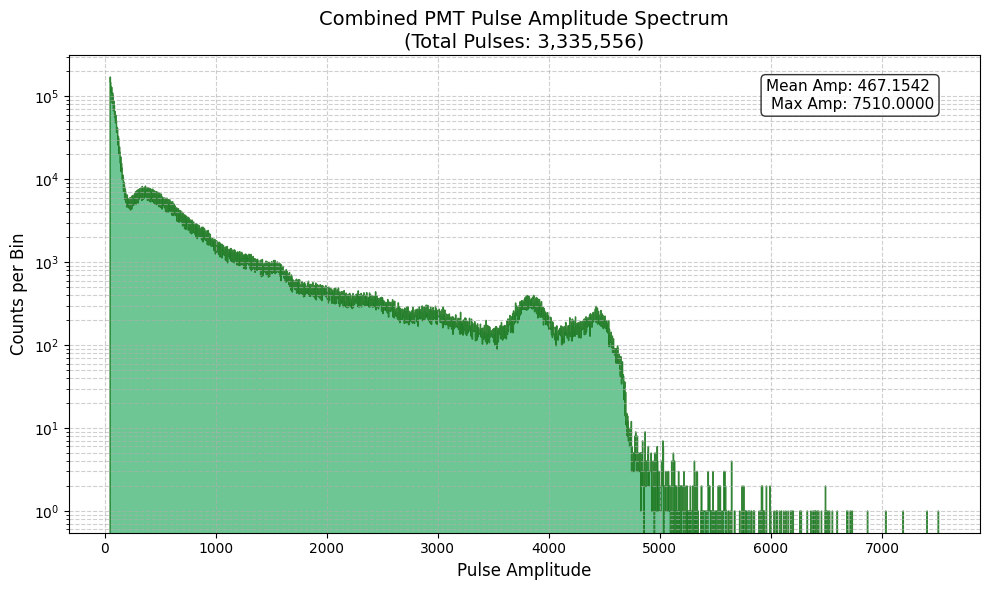

In [1]:
import os
import glob
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

def extract_pulse_amplitudes(file_path, data_format='int16', chunk_size=10_000_000, invert_signal=False):
    """
    Reads PMT data in chunks from disk, finds pulse peaks, and returns them.
    This prevents MemoryErrors on extremely large files.
    """
    if not os.path.exists(file_path):
        print(f"Error: File '{file_path}' not found.")
        return []

    # 1. Use memmap to map the file from disk without loading it all into RAM
    data = np.memmap(file_path, dtype=data_format, mode='r')
    total_points = len(data)
    
    # Pulse parameters
    noise_threshold = 50
    min_samples_between_pulses = 10 
    
    # Create an overlap buffer so we don't split a pulse across two chunks
    overlap = min_samples_between_pulses * 2 
    
    all_peak_amplitudes = []

    # 2. Process the file in chunks
    for start_idx in range(0, total_points, chunk_size):
        end_idx = min(start_idx + chunk_size + overlap, total_points)
        
        # Extract just this specific chunk into active memory
        chunk = data[start_idx:end_idx]
        
        if invert_signal:
            analyze_chunk = chunk * -1
        else:
            analyze_chunk = chunk
            
        # Find peaks in this chunk
        peaks, _ = find_peaks(analyze_chunk, height=noise_threshold, distance=min_samples_between_pulses)
        
        # 3. Prevent double-counting in the overlap region
        if end_idx < total_points:
            valid_peaks = peaks[peaks < chunk_size]
        else:
            valid_peaks = peaks
            
        # Get the actual voltage values for these peaks
        chunk_amplitudes = chunk[valid_peaks]
        all_peak_amplitudes.extend(chunk_amplitudes)
        
    print(f"  -> Found {len(all_peak_amplitudes):,} pulses (processed {total_points:,} points).")
    
    return all_peak_amplitudes

def plot_amplitude_histogram(amplitudes, num_bins=512, log_scale=True):
    """
    Takes an array of pulse amplitudes and plots them as a histogram (spectrum).
    """
    if amplitudes is None or len(amplitudes) == 0:
        print("Error: The amplitudes array is empty. No pulses were found.")
        return

    print(f"\nPlotting combined histogram for {len(amplitudes):,} detected pulses...")

    plt.figure(figsize=(10, 6))
    
    # Plot the histogram using 'stepfilled'
    counts, bins, patches = plt.hist(amplitudes, bins=num_bins, color='mediumseagreen', 
                                     alpha=0.75, histtype='stepfilled', edgecolor='darkgreen')
    
    # Apply Logarithmic Scale
    if log_scale:
        plt.yscale('log')
        plt.grid(True, linestyle='--', alpha=0.6, which='both') 
    else:
        plt.grid(True, linestyle='--', alpha=0.6)

    # Stats
    mean_amp = np.mean(amplitudes)
    max_amp = np.max(amplitudes)
    
    plt.title(f"Combined PMT Pulse Amplitude Spectrum\n(Total Pulses: {len(amplitudes):,})", fontsize=14)
    plt.xlabel("Pulse Amplitude", fontsize=12)
    plt.ylabel("Counts per Bin", fontsize=12)
    
    # Add a text box with statistics
    stats_text = f"Mean Amp: {mean_amp:.4f} \nMax Amp: {max_amp:.4f}"
    plt.text(0.95, 0.95, stats_text, transform=plt.gca().transAxes, 
             fontsize=11, verticalalignment='top', horizontalalignment='right',
             bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

    plt.tight_layout()
    plt.show()


# ==========================================
# Main Execution Block
# ==========================================

# 1. Define the folder containing your files
folder_path = r"C:\Users\Berkeley\Documents\CERES\pmt100k_hz_files"

# 2. Find all .BINPMT files in that folder
file_pattern = os.path.join(folder_path, "*.BINPMT")
file_list = glob.glob(file_pattern)

if not file_list:
    print(f"No .BINPMT files found in {folder_path}")
else:
    print(f"Found {len(file_list)} files to process.\n")

    # List to hold all amplitudes across all files
    all_amplitudes = []

    # 3. Loop through the files
    for file_path in file_list:
        file_name = os.path.basename(file_path)
        print(f"Processing: {file_name}")
        
        # Extract pulses (processing in chunks to save memory)
        # Replaced num_points with chunk_size
        file_amplitudes = extract_pulse_amplitudes(file_path, chunk_size=10_000_000, invert_signal=False)
        
        # Add the extracted amplitudes to our master list
        if file_amplitudes is not None and len(file_amplitudes) > 0:
            all_amplitudes.extend(file_amplitudes)

    # 4. Convert the combined list to a numpy array for plotting
    all_amplitudes = np.array(all_amplitudes)

    # 5. Plot the combined spectrum!
    plot_amplitude_histogram(all_amplitudes, num_bins=2048, log_scale=True)

# For the weekend run on 4/4/2026 with Faraday cage closed and the lights off

Successfully loaded 250,500,000 data points.
------------------------------
Calculated True Baseline (Median): -19.000000
Skewed Average (Mean):             -5.372829
------------------------------


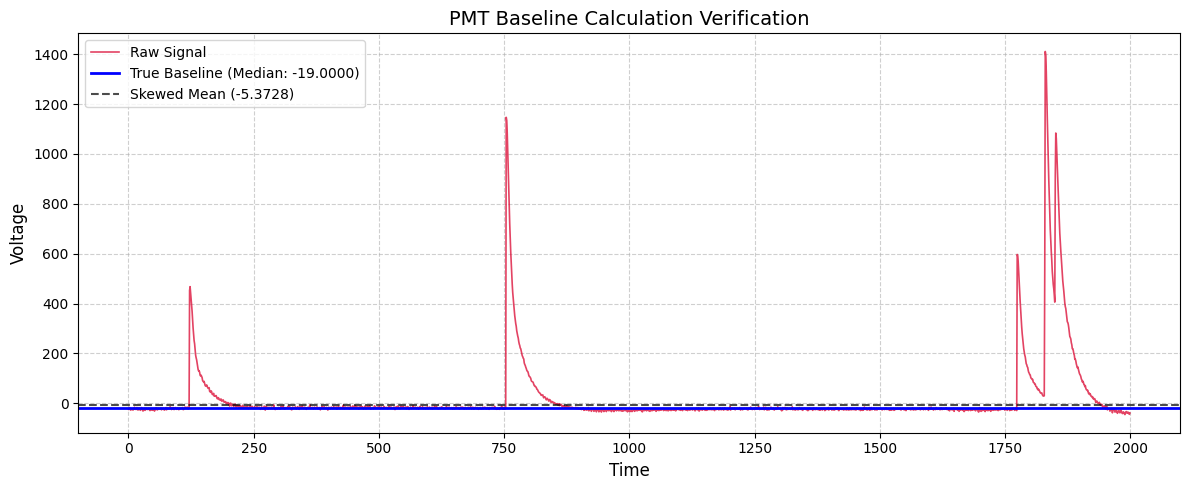

TypeError: extract_pulse_amplitudes() got an unexpected keyword argument 'num_points'

In [26]:
my_file = r"C:\Users\Berkeley\Documents\CERES\pmt100k_hz_files\20260404_06h20.BINPMT"

data = np.fromfile(my_file, dtype=np.int16)
print(f"Successfully loaded {len(data):,} data points.")

baseline_voltage = calculate_pmt_baseline(my_file, data_format='int16', analyze_points=2500000)
amplitudes = extract_pulse_amplitudes(my_file, data_format="int16", num_points= 2505000, invert_signal=False)
plot_amplitude_histogram(amplitudes, num_bins=256, log_scale=True)

graph_pulse_amplitudes(my_file, data_format="int16", num_points= 250000, invert_signal=False)
graph_pulse_amplitudes(my_file, data_format="int16", start_idx=62000, num_points= 2500, invert_signal=False)
graph_pulse_amplitudes(my_file, data_format="int16", start_idx=62000, num_points= 250, invert_signal=False)

Found 14755 pulses in this data window.
Plotting histogram for 14,755 detected pulses...


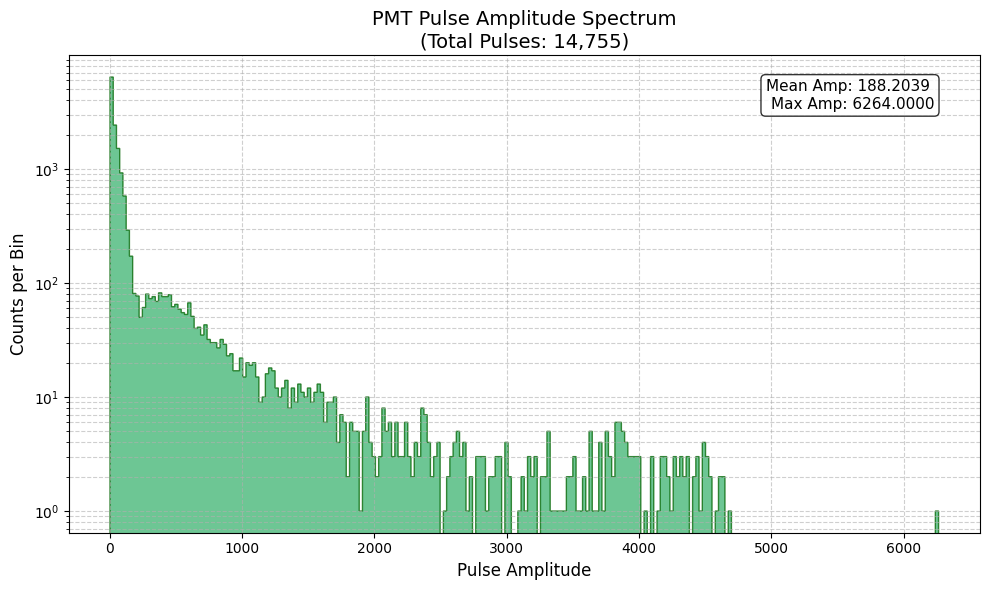

Found 14101 pulses in this data window.
Plotting histogram for 14,101 detected pulses...


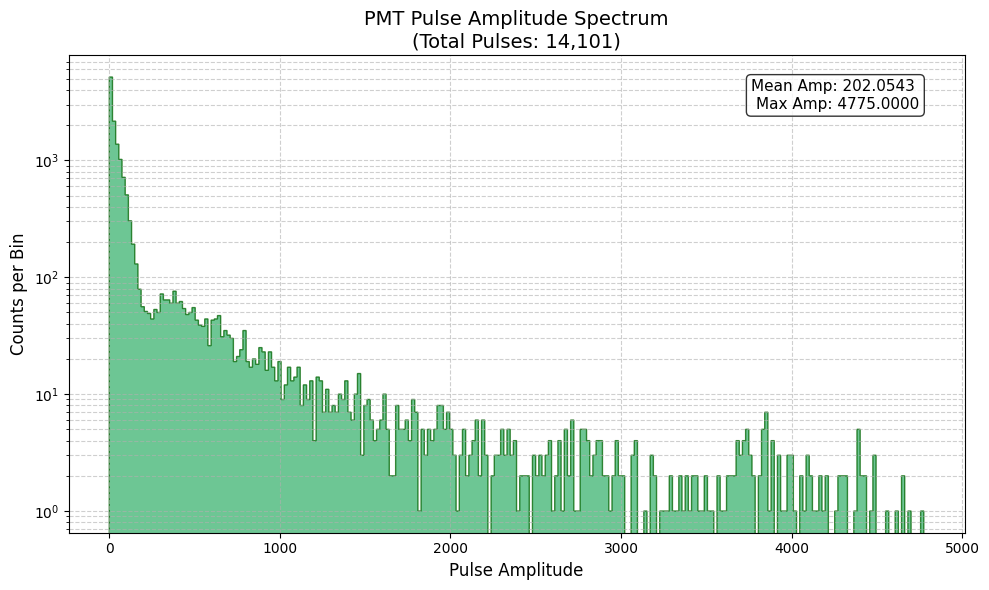

Found 14872 pulses in this data window.
Plotting histogram for 14,872 detected pulses...


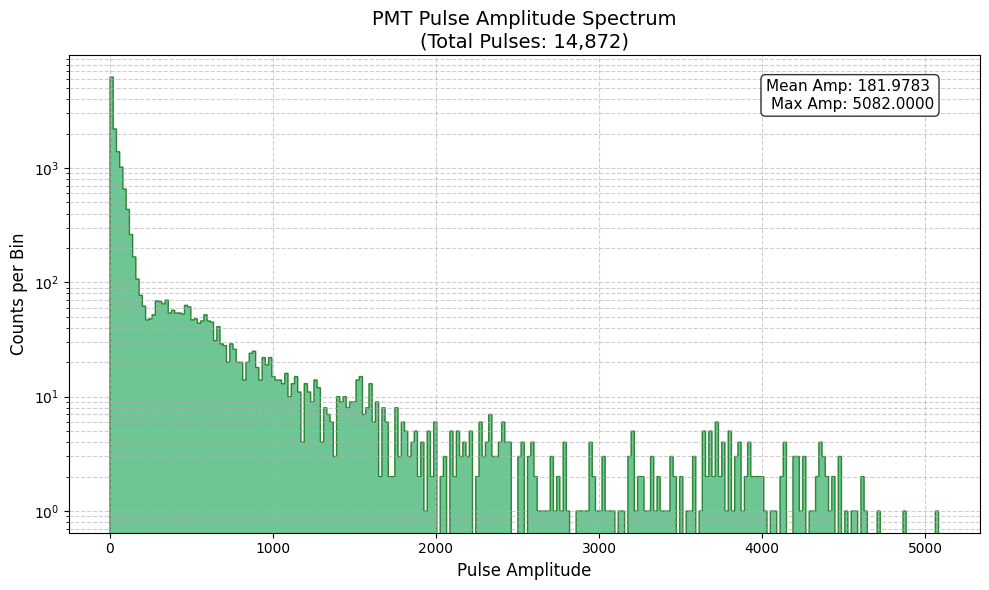

Found 15477 pulses in this data window.
Plotting histogram for 15,477 detected pulses...


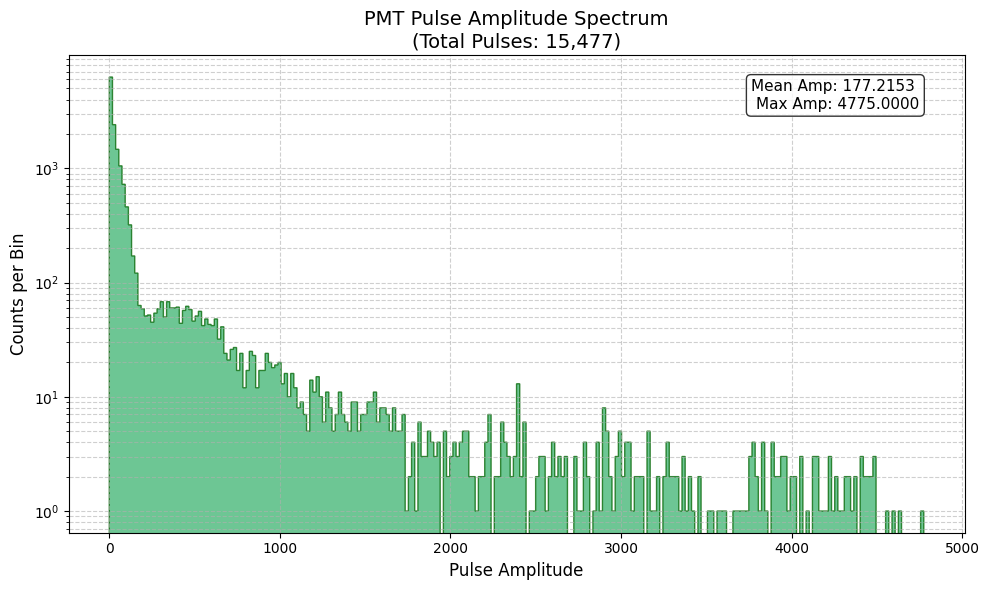

In [ ]:
# Specify the folder path
folder_path = r"C:\Users\Berkeley\Documents\CERES\pmt100k_hz_files"

# LOOP
for filename in os.listdir(folder_path):
    # os.listdir only gives the file name, so we need to join it with the folder path
    full_file_path = os.path.join(folder_path, filename)
    
    # Make sure it's a file and not a sub-folder
    if os.path.isfile(full_file_path):
        amplitudes = extract_pulse_amplitudes(full_file_path, data_format='int16', start_idx=0, num_points=2500000, invert_signal=False)
        plot_amplitude_histogram(amplitudes, num_bins=256, log_scale=True)

# 80 Second Test Run

In [ ]:
my_file = r"C:\Users\Berkeley\Documents\CERES\pmt5000hrtzfiles\20260331_15h50.BINPMT"
amplitudes = extract_pulse_amplitudes(my_file, data_format="int16", start_idx=560, num_points=20, invert_signal=False)
print(amplitudes)

Found 1 pulses in this data window.
[3776]


In [ ]:
print(amplitudes[0])
print(f"Amplitude - Median Baseline: {int(amplitudes[0]) - 58:.4f}")

3776
Amplitude - Median Baseline: 3718.0000


In [ ]:
my_file = r"C:\Users\Berkeley\Documents\CERES\pmt5000hrtzfiles\20260331_15h50.BINPMT"
amplitudes = extract_pulse_amplitudes(my_file, data_format="int16", start_idx=1290, num_points=20, invert_signal=False)
print(amplitudes)
print(amplitudes[0])
print(f"Amplitude - Median Baseline: {int(amplitudes[0]) - 58:.4f}")

Found 1 pulses in this data window.
[1581]
1581
Amplitude - Median Baseline: 1523.0000


# Not really used 

C:\Users\Berkeley\AppData\Local\Temp\ipykernel_4136\2293267965.py:49: RuntimeWarning: invalid value encountered in multiply
  plt.plot(x_data, y_data * -1, color='crimson', linewidth=1.5)


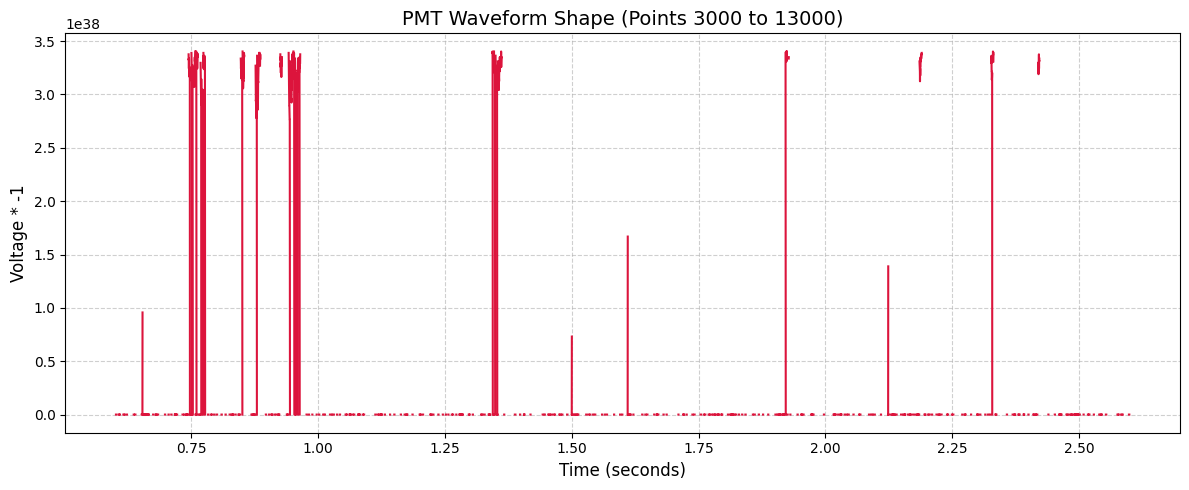

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt

def plot_pmt_waveforms(file_path, data_format='int32', start_idx=0, num_points=2000, sample_rate_hz=None):
    """
    Reads a binary file and plots the raw time-series waveform (pulse shapes).
    
    Parameters:
    file_path (str): The path to your binary file.
    data_format (str): The specific 32-bit format ('float32', 'int32', 'uint32').
    start_idx (int): The index of the first data point to plot.
    num_points (int): How many data points to plot. Keep this relatively small 
                      (e.g., 500 - 10000) to actually see the pulse shapes.
    sample_rate_hz (float): Optional. If provided, converts the x-axis to time (seconds).
    """
    
    if not os.path.exists(file_path):
        print(f"Error: The file '{file_path}' was not found.")
        return

    try:
        # Read the binary data
        data = np.fromfile(file_path, dtype=data_format)
        total_points = len(data)
        
        # Validation to ensure we don't index out of bounds
        if start_idx >= total_points:
            print(f"Error: start_idx ({start_idx}) is greater than total data points ({total_points}).")
            return
            
        end_idx = min(start_idx + num_points, total_points)
        y_data = data[start_idx:end_idx]
        
        # Determine X-axis (either Time or raw Index)
        if sample_rate_hz:
            # Create a time array in seconds
            x_data = np.arange(start_idx, end_idx) / sample_rate_hz
            x_label = "Time (seconds)"
        else:
            x_data = np.arange(start_idx, end_idx)
            x_label = "Sample Index"

        # Create the graph
        plt.figure(figsize=(12, 5))
        
        # Plotting the waveform. We use a thin line to see the pulse shapes clearly.
        # You can add marker='.' to the plot arguments if you want to see the exact sample points.
        plt.plot(x_data, y_data * -1, color='crimson', linewidth=1.5)
        
        plt.title(f"PMT Waveform Shape (Points {start_idx} to {end_idx})", fontsize=14)
        plt.xlabel(x_label, fontsize=12)
        plt.ylabel("Voltage * -1", fontsize=12) 
        plt.grid(True, linestyle='--', alpha=0.6)
        
        plt.tight_layout()
        plt.show()

    except Exception as e:
        print(f"An error occurred while processing the file: {e}")

# Example Usage:
my_file = r"C:\Users\Berkeley\Documents\CERES\pmt5000hrtzfiles\20260331_15h50.BINPMT"
plot_pmt_waveforms(my_file, data_format='float32', start_idx=3000, num_points=10000, sample_rate_hz=5000)

Successfully loaded 225,000 data points.


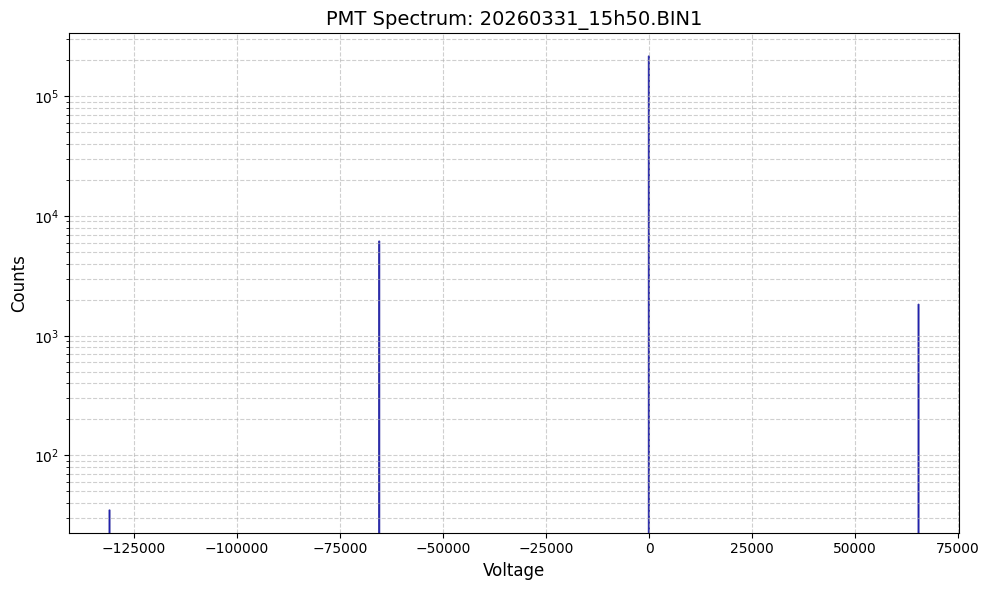

Successfully loaded 225,000 data points.


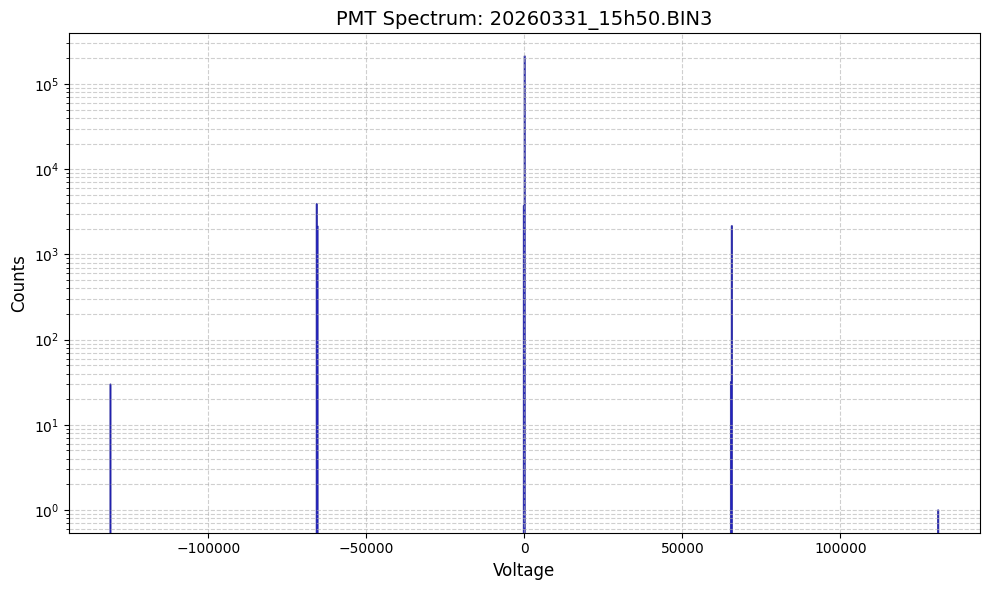

Successfully loaded 225,000 data points.


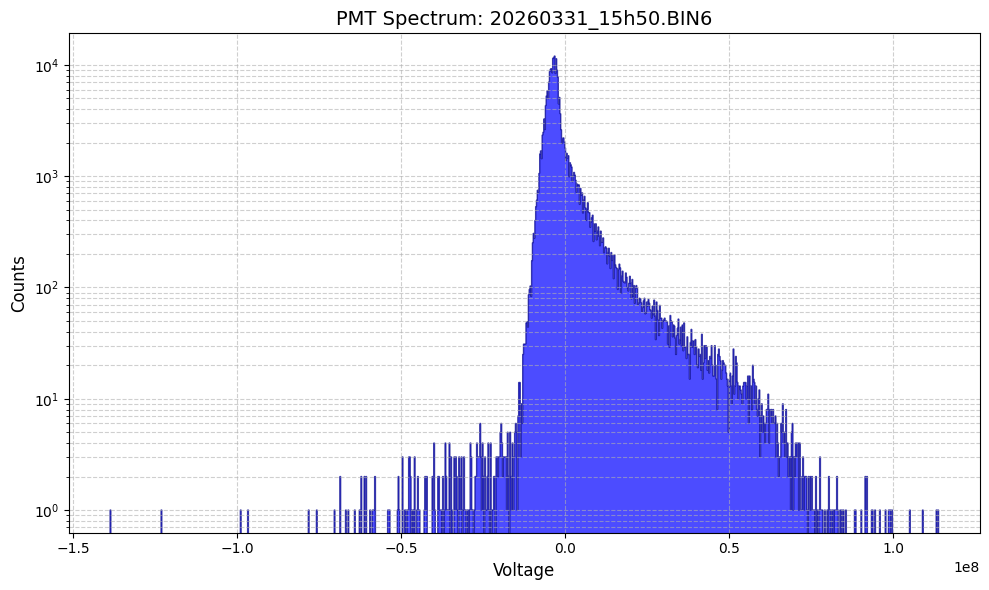

Successfully loaded 225,000 data points.


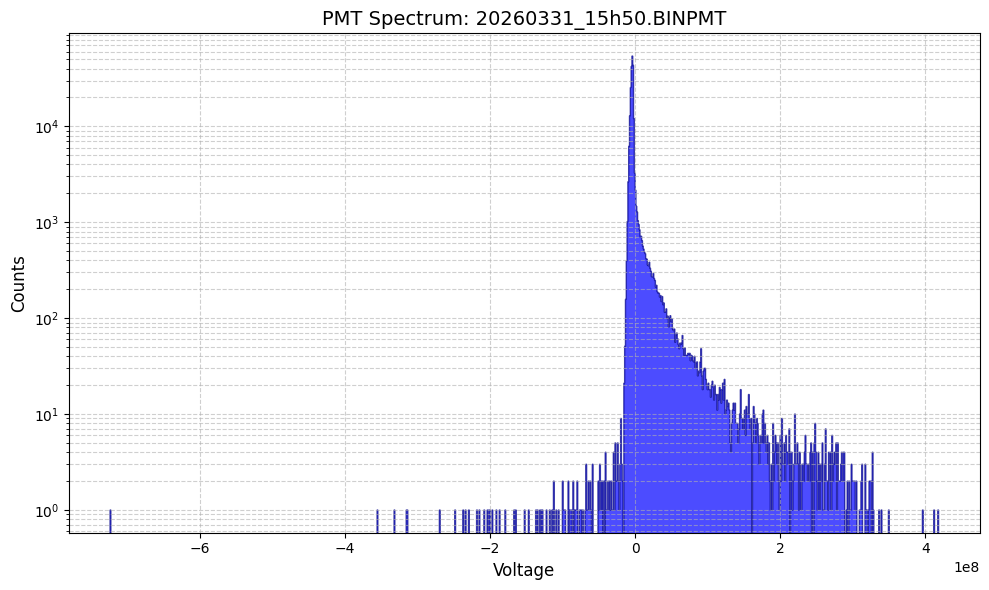

In [ ]:
# Specify the folder path
folder_path = r"C:\Users\Berkeley\Documents\CERES\pmt5000hrtzfiles"

# LOOP
for filename in os.listdir(folder_path):
    # os.listdir only gives the file name, so we need to join it with the folder path
    full_file_path = os.path.join(folder_path, filename)
    
    # Make sure it's a file and not a sub-folder
    if os.path.isfile(full_file_path):
        graph_pmt_spectrum(full_file_path, data_format='int32', num_bins=1024, log_scale=True)

Successfully loaded 225000 data points.


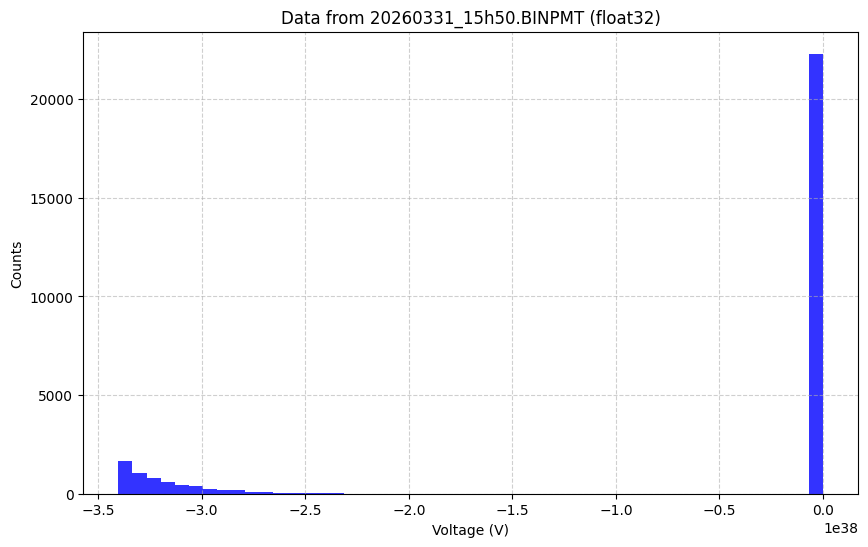

In [ ]:
def graph_pmt(file_path, data_format='float32'):
    """
    Reads a 32-bit binary file and plots the data.
    
    Parameters:
    file_path (str): The path to your binary file.
    data_format (str): The specific 32-bit format. 
                       Common options: 'float32', 'int32', or 'uint32'.
    """
    
    # Check if the file exists
    if not os.path.exists(file_path):
        print(f"Error: The file '{file_path}' was not found.")
        return

    try:
        # Read the binary file into a numpy array
        data = np.fromfile(file_path, dtype=data_format)
        
        print(f"Successfully loaded {len(data)} data points.")
        
        # Create the graph
        plt.figure(figsize=(10, 6))
        plt.hist(data, bins=50,color='b', alpha=0.8)
        
        # Add labels and title
        plt.title(f"Data from {os.path.basename(file_path)} ({data_format})")
        plt.xlabel("Voltage (V)")
        plt.ylabel("Counts")
        plt.grid(True, linestyle='--', alpha=0.6)
        
        # Display the plot
        plt.show()

    except Exception as e:
        print(f"An error occurred while processing the file: {e}")

my_file = r"\Users\Berkeley\Documents\CERES\pmt5000hrtzfiles\20260331_15h50.BINPMT"
graph_pmt(my_file, data_format='float32')

Successfully loaded 450,000 data points.


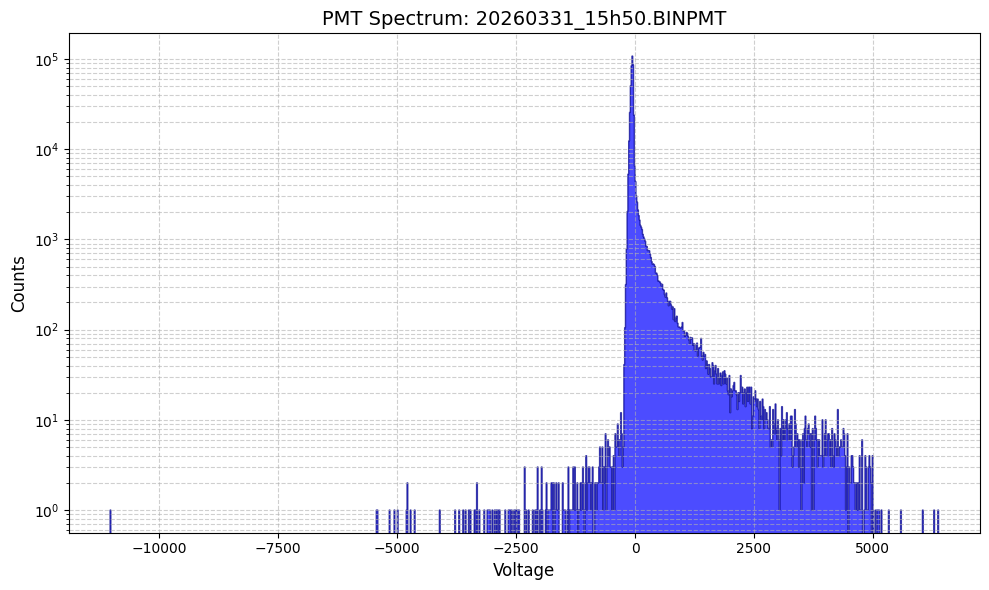

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt

def graph_pmt_spectrum(file_path, data_format='int16', num_bins=1024, log_scale=True):
    """
    Reads a 32-bit binary file and plots the PMT spectrum (histogram).
    
    Parameters:
    file_path (str): The path to your binary file.
    data_format (str): The specific 32-bit format ('float32', 'int32', 'uint32').
    num_bins (int or str): Number of histogram bins. 1024 or 'auto' is standard.
    log_scale (bool): Whether to use a logarithmic scale for the y-axis (Counts).
    """
    
    # Check if the file exists
    if not os.path.exists(file_path):
        print(f"Error: The file '{file_path}' was not found. Check the path.")
        return

    try:
        # Read the binary file into a numpy array
        data = np.fromfile(file_path, dtype=data_format)
        print(f"Successfully loaded {len(data):,} data points.")
        
        # Create the graph
        plt.figure(figsize=(10, 6))
        
        # 'stepfilled' good for spectra display
        plt.hist(data, bins=num_bins, color='blue', alpha=0.7, histtype='stepfilled', edgecolor='darkblue')
        
        # Apply logarithmic scale if requested
        if log_scale:
            plt.yscale('log')
            # 'both' ensures the grid lines show up nicely for minor log ticks
            plt.grid(True, linestyle='--', alpha=0.6, which='both') 
        else:
            plt.grid(True, linestyle='--', alpha=0.6)
            
        # Add labels and title
        plt.title(f"PMT Spectrum: {os.path.basename(file_path)}", fontsize=14)
        plt.xlabel("Voltage", fontsize=12) 
        plt.ylabel("Counts", fontsize=12)
        
        # Optimize layout to prevent label cutoff
        plt.tight_layout()
        
        # Display the plot
        plt.show()

    except Exception as e:
        print(f"An error occurred while processing the file: {e}")

my_file = r"C:\Users\Berkeley\Documents\CERES\pmt5000hrtzfiles\20260331_15h50.BINPMT"

# 1024 bins is a standard Multi-Channel Analyzer (MCA) resolution. 
graph_pmt_spectrum(my_file, data_format='int16', num_bins=1024, log_scale=True)